In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from scipy.interpolate import interp1d
from matplotlib.ticker import MultipleLocator

In [5]:
arr0 = np.load("..\Data\MAC_SWEEP\Bank0_1x_TD_Sweep_1_Ref256.npy")
arr1 = np.load("..\Data\MAC_SWEEP\Bank1_1x_TD_Sweep_4.npy")
arr2 = np.load("..\Data\MAC_SWEEP\Bank2_1x_TD_Sweep_4.npy")
arr3 = np.load("..\Data\MAC_SWEEP\Bank3_1x_TD_Sweep_4.npy")
arr = np.concatenate((arr0, arr0, arr0, arr0), axis=1)
#arr1 = np.load("..\Data\Bank1_1x_TD_Sweep_4_Calib.npy")
#arr = arr0
print(arr.shape)
test_arr = arr.reshape(arr.shape[0],16,int(arr.shape[1]/16))
for i in range(arr.shape[0]):
    for j in range(16):
        if(np.all(test_arr[i,j,:]==0)):
            print("Problem",i,j)

(257, 256)


In [3]:
arr0 = np.load("..\Data\MAC_SWEEP\Bank0_2x_TD_Sweep_4.npy")
arr1 = np.load("..\Data\MAC_SWEEP\Bank1_2x_TD_Sweep_4.npy")
arr2 = np.load("..\Data\MAC_SWEEP\Bank2_2x_TD_Sweep_4.npy")
arr3 = np.load("..\Data\MAC_SWEEP\Bank3_2x_TD_Sweep_4.npy")
arr = np.concatenate((arr0, arr1, arr2, arr3), axis=1)
arr.shape
print(arr0.shape)
#Check if for each input in each bank and bl if all data lines are giving 0.
test_arr = arr.reshape(arr.shape[0],16,int(arr.shape[1]/16)) #Inputs * (B0-0,1,2,3 B1-0,1,2,3 ...) * DLs
for i in range(arr.shape[0]):
    for j in range(16):
        if(np.all(test_arr[i,j,:]==0)):
            print("Problem",i,j)
test_arr[64,7,:]

(65, 256)


array([255, 239, 250, 256, 268, 258, 263, 254, 249, 264, 258, 258, 255,
       251, 256, 263, 262, 266, 256, 255, 265, 255, 256, 255, 250, 254,
       259, 255, 253, 264, 260, 246, 256, 257, 254, 273, 262, 266, 266,
       262, 263, 257, 260, 267, 255, 254, 252, 256, 255, 254, 251, 255,
       256, 256, 260, 256, 252, 262, 255, 260, 262, 259, 260, 261])

In [6]:
temp = arr0[256,:]
print(temp.shape)
print(temp[0:64])
print(temp[64:128])
print(temp[128:192])
print(temp[192:256])

(64,)
[-2  0  0  0 -2 -1  0  0  0 -2  0 -3 -1 -3 -3 -1 -3 -1 -3 -3 -4  0 -6 -2
  1  0  0  1  0  1  1  0  0 -2  0  0  0  0  0  0 -2  0  0  0  0  0  0  0
  1  0 -1 -1  0  0  0  0  1  0  0  1  0  0  0  2]
[]
[]
[]


(257, 256)


C:\Users\91880\AppData\Local\Temp\ipykernel_5452\1079563977.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Blues')
C:\Users\91880\AppData\Local\Temp\ipykernel_5452\1079563977.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap2 = cm.get_cmap('Greens')


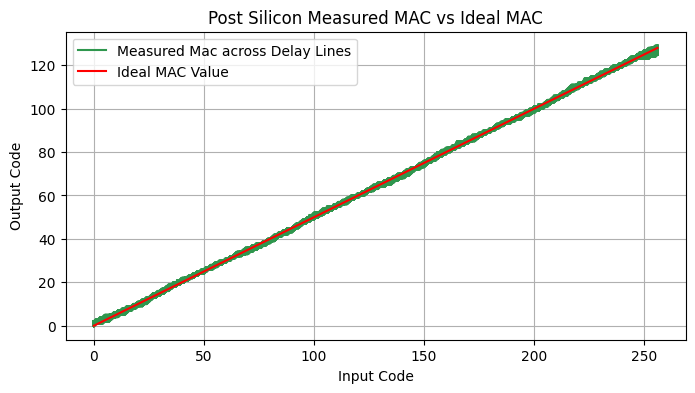

In [6]:
ideal_mac = np.arange(0,128.5,0.5)
x_axis = list(range(0,257,1))
print(arr.shape)
corrected = []
error = []
cmap = cm.get_cmap('Blues')
cmap2 = cm.get_cmap('Greens')
fig, ax = plt.subplots(figsize=(8, 4))
plt.title("Post Silicon Measured MAC vs Ideal MAC")
plt.xlabel("Input Code")
plt.ylabel("Output Code")
for i in range(0,arr.shape[1],1):
    d1 = arr[:,i]
    m, c = np.polyfit(d1,ideal_mac , 1)
    d2 = np.round(d1*m+c)
    #plt.plot(ideal_mac, 2*d1, color = cmap(0.3))
    plt.plot(x_axis, d2, color = cmap2(0.7))
    corrected.append(d2)
    error.append(d2 - ideal_mac)
corrected = np.array(corrected)
for point in [50,130,200]:
    mean = np.mean(corrected[:,round(point/4)])
    std = np.std(corrected[:,round(point/4)])
    # Main plot arrow (pointing to feature of interest)
    #ax.text(point,point-20,f'σ={std:0.3f}',fontsize=10)
    #ax.errorbar(point, point, yerr=std*10, fmt='o', color='blue', capsize=5, markersize=3)
plt.plot(x_axis, d2, color = cmap2(0.7), label = "Measured Mac across Delay Lines")
plt.plot(x_axis, ideal_mac,color = "Red", label = "Ideal MAC Value")
plt.legend() 
plt.grid(True)
plt.show()

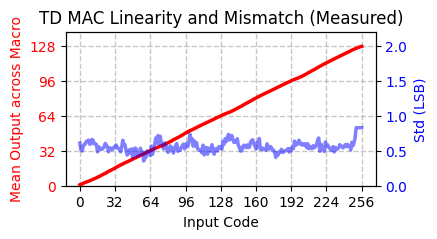

In [7]:
mean_corrected = np.mean(corrected,axis=0)
std_corrected = np.std(corrected,axis=0)
#std_corrected = std_corrected[:len(std_corrected)-5]
std_corrected[len(std_corrected)-6:len(std_corrected)] = std_corrected[len(std_corrected)-6]
fig, ax1 = plt.subplots(figsize=(4, 2))

# First plot (left y-axis)
ax1.plot(x_axis, mean_corrected, color="r",linewidth=2.5)
ax1.set_xlabel("Input Code")
ax1.set_ylabel("Mean Output across Macro", color="r")
ax1.tick_params(axis="y", labelcolor="r")
ax1.set_ylim(0, 140.8)
ax1.yaxis.set_major_locator(MultipleLocator(32))

# Second plot (right y-axis)
ax2 = ax1.twinx()
ax2.plot( std_corrected, color="b",alpha=0.5,linewidth=2.5)
ax2.set_ylabel("Std (LSB)", color="b")
ax2.tick_params(axis="y", labelcolor="b")
ax2.set_ylim(0, 2.2)
ax2.yaxis.set_major_locator(MultipleLocator(0.5))



plt.xticks(range(0, 257,32)) 
# Optional: title
plt.title("TD MAC Linearity and Mismatch (Measured)")
ax1.grid(True, which='major', linestyle='--', linewidth=1, alpha=0.7)
ax1.grid(True, which='minor', linestyle=':', linewidth=1, alpha=0.5)
#plt.savefig("D:\ISSCC_26\Graphs\TD_1x_Acc.jpg", dpi=800, bbox_inches="tight")
plt.show()

In [8]:
print(np.mean(std_corrected))

0.5609738787978107


In [ ]:
corrected_mac = np.transpose(corrected)
corrected_mac = np.reshape(corrected_mac,(257,4,1,64))
corrected_mac = corrected_mac[:,:,0,:]
corrected_mac.shape


In [ ]:
HW_MODEL_TD_1x = np.zeros(((4,64,257)),dtype=np.float32)
x_new = np.arange(0, 257, 1)   # length 257
x_orig = np.arange(0, 257, 1)  # length 65
# Interpolation
for bank in range(4):
    for dl in range(64):
        a = corrected_mac[:,bank,dl]
        HW_MODEL_TD_1x[bank,dl] = a #np.interp(x_new, x_orig, a)
        plt.plot(HW_MODEL_TD_1x[bank,dl])
np.save("d:\Chip2025\Chip2025_Testing\Python_Notebook\Tests\Data\Hardware_Model\HW_MODEL_TD_1x.npy",HW_MODEL_TD_1x)

In [ ]:
print(HW_MODEL_TD_1x[0,9])

In [ ]:
sigma = []
for i in range(0,arr.shape[1],1):
    plt.plot(ideal_mac, error[i], label='Data', color = cmap2(0.7))
    sigma.append(np.std(error[i]))
print(np.mean(sigma))

In [9]:
def compute_dnl_inl(actual_2d, ideal_1d):
    ideal_diff = np.diff(ideal_1d)
    ideal_lsb = np.mean(ideal_diff)

    # Compute DNL: difference of step sizes from ideal LSB
    dnl = (np.diff(actual_2d, axis=1) / ideal_lsb) -1

    # Compute INL: deviation from ideal (cumulative DNL)
    inl = np.cumsum(dnl, axis=1)

    # Pad DNL and INL to match original array length
    dnl = np.pad(dnl, ((0, 0), (0, 1)), mode='edge')
    inl = np.pad(inl, ((0, 0), (0, 1)), mode='edge')

    return dnl, inl

In [10]:
dnl,inl = compute_dnl_inl(corrected,ideal_mac)

C:\Users\91880\AppData\Local\Temp\ipykernel_5452\562033030.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Blues')


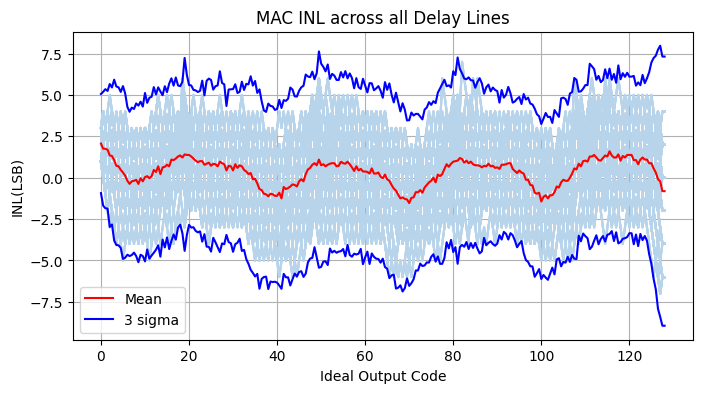

In [18]:
mean_inl = np.mean(inl, axis=0)
plt.figure(figsize=(8, 4))
plt.title("MAC INL across all Delay Lines")
plt.xlabel("Ideal Output Code")
plt.ylabel("INL(LSB)")
cmap = cm.get_cmap('Blues')
# Standard deviation (sigma) per code index
sigma_inl = np.std(inl, axis=0)
mean_inl = mean_inl + 2
plus_3sigma = mean_inl + 3 * sigma_inl
minus_3sigma = mean_inl - 3 * sigma_inl
for i,j in zip(inl,dnl):
    plt.plot(ideal_mac, i+2, color=cmap(0.3))
plt.plot(ideal_mac, mean_inl, color = "red",label = "Mean")
plt.plot(ideal_mac, plus_3sigma, color = "blue",label = "3 sigma")
plt.plot(ideal_mac, minus_3sigma,color = "blue")
plt.legend() 
plt.grid(True)
plt.show()


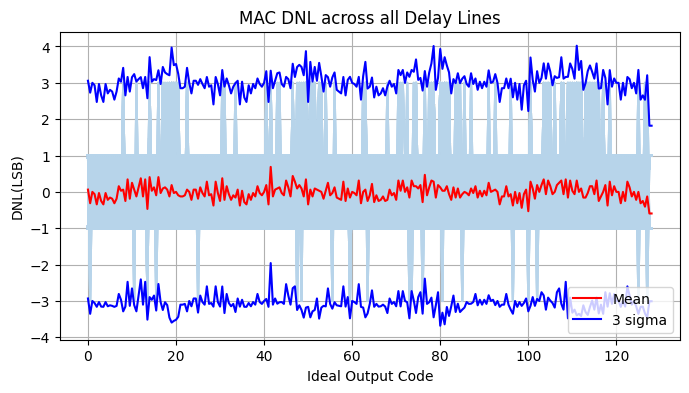

In [19]:
mean_dnl = np.mean(dnl, axis=0)
plt.figure(figsize=(8, 4))
plt.title("MAC DNL across all Delay Lines")
plt.xlabel("Ideal Output Code")
plt.ylabel("DNL(LSB)")
# Standard deviation (sigma) per code index
sigma_dnl = np.std(dnl, axis=0)
plus_3sigma = mean_dnl + 3 * sigma_dnl
minus_3sigma = mean_dnl - 3 * sigma_dnl
for i,j in zip(inl,dnl):
    plt.plot(ideal_mac, j,color=cmap(0.3))
plt.plot(ideal_mac, mean_dnl, color = "red",label = "Mean")
plt.plot(ideal_mac, plus_3sigma,color = "blue",label = "3 sigma" )
plt.plot(ideal_mac, minus_3sigma,color = "blue")
plt.legend() 
plt.grid(True)
plt.show()